# Baseline B — full record

The complete log of the standard-RAG (B) experiments: every variant, the retrieval bottleneck, the top-k / top-n interaction, and the observations. `../02_comparison` keeps only the headline best; this is the detailed record for the report.

Auto-loads every `outputs/results*.json`, so new experiments appear without edits.

In [6]:
import json, os, re, glob, string
import matplotlib.pyplot as plt

OUT = '../../outputs'
BASE = '/work/cvcs2026/encyclopedic'

# filename -> (label, what it tests)
DESC = {
    'results.json':              ('A: no-RAG', 'VLM only (image + question)'),
    'results_rag.json':          ('B1: top1 + first3', 'top-1 article, first 3 sections, no rerank'),
    'results_B2.json':           ('B2: top1 + allsec', 'top-1 article, all sections, no rerank'),
    'results_B2_1.json':         ('B2.1: top5 + allsec', 'top-5 articles, all sections, no rerank'),
    'results_B3.json':           ('B3: top5 + CLIP', 'top-5 + CLIP rerank (top-3)'),
    'results_B4.json':           ('B4: top5 + cross3', 'top-5 + cross-encoder (top-3)'),
    'results_B4_1.json':         ('B4.1: top5 + cross15', 'top-5 + cross-encoder (top-15)'),
    'results_B5_top20.json':     ('B5: top20 + cross5', 'top-20 + cross-encoder (top-5)'),
    'results_B5_top50.json':     ('B5: top50 + cross5', 'top-50 + cross-encoder (top-5)'),
    'results_B5_top50_n20.json': ('B5: top50 + cross20', 'top-50 + cross-encoder (top-20)'),
    'results_B5_top50_n30.json': ('B5: top50 + cross30', 'top-50 + cross-encoder (top-30)'),
}

rows = []
for f in sorted(glob.glob(OUT + '/results*.json')):
    name = os.path.basename(f)
    r = json.load(open(f))
    label, desc = DESC.get(name, (name.replace('results_', '').replace('.json', ''), ''))
    rows.append((label, desc, r['accuracy_overall'], r['accuracy_by_type']))
rows.sort(key=lambda x: x[2], reverse=True)
print('%-24s %-8s %s' % ('variant', 'overall', 'what it tests'))
for label, desc, ov, _ in rows:
    print('%-24s %.3f    %s' % (label, ov, desc))

variant                  overall  what it tests
B5: top50 + cross20      0.401    top-50 + cross-encoder (top-20)
B5: top50 + cross30      0.385    top-50 + cross-encoder (top-30)
B5: top50 + cross5       0.376    top-50 + cross-encoder (top-5)
B5: top20 + cross5       0.364    top-20 + cross-encoder (top-5)
B4: top5 + cross3        0.360    top-5 + cross-encoder (top-3)
B4.1: top5 + cross15     0.355    top-5 + cross-encoder (top-15)
B2.1: top5 + allsec      0.347    top-5 articles, all sections, no rerank
B2: top1 + allsec        0.295    top-1 article, all sections, no rerank
B1: top1 + first3        0.278    top-1 article, first 3 sections, no rerank
A: no-RAG                0.245    VLM only (image + question)
B3: top5 + CLIP          0.243    top-5 + CLIP rerank (top-3)


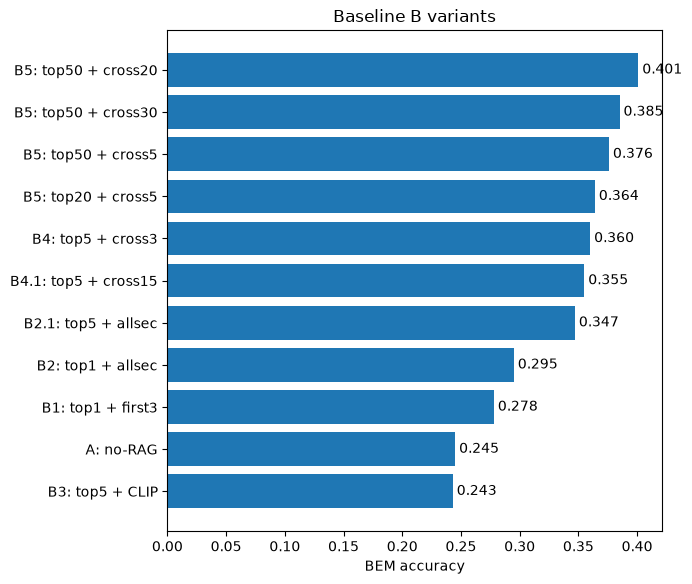

In [7]:
labels = [r[0] for r in rows][::-1]
vals = [r[2] for r in rows][::-1]
plt.figure(figsize=(7, 0.45 * len(labels) + 1))
plt.barh(labels, vals)
for i, v in enumerate(vals):
    plt.text(v, i, ' %.3f' % v, va='center')
plt.xlabel('BEM accuracy'); plt.title('Baseline B variants'); plt.tight_layout(); plt.show()

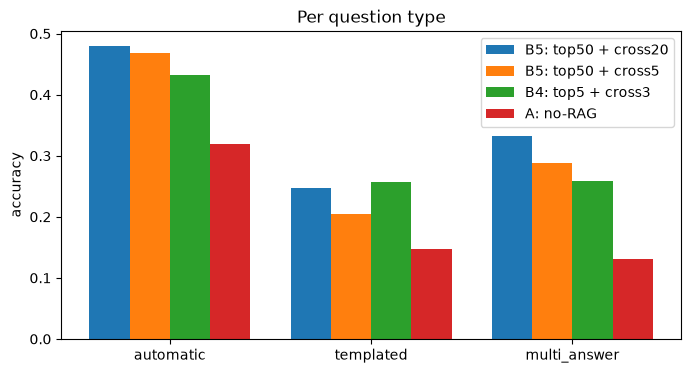

In [8]:
types = ['automatic', 'templated', 'multi_answer']
focus = ['A: no-RAG', 'B4: top5 + cross3', 'B5: top50 + cross5', 'B5: top50 + cross20']
sel = [(l, byt) for l, _, _, byt in rows if l in focus]
x = range(len(types)); w = 0.8 / max(len(sel), 1)
plt.figure(figsize=(8, 4))
for i, (l, byt) in enumerate(sel):
    off = (i - (len(sel) - 1) / 2) * w
    plt.bar([j + off for j in x], [byt.get(t, 0) for t in types], w, label=l)
plt.xticks(list(x), types); plt.ylabel('accuracy'); plt.legend(); plt.title('Per question type'); plt.show()

## Retrieval is the bottleneck
Split examples by whether the correct article is among the retrieved candidates, then measure answer accuracy on each subset (exact-match proxy, a floor of BEM; the hit-vs-miss gap is the signal).

file: predictions_B5_top50_n20.jsonl
recall (article retrieved): 46.7%
accuracy | HIT : 0.124 (n=467)
accuracy | MISS: 0.030 (n=533)


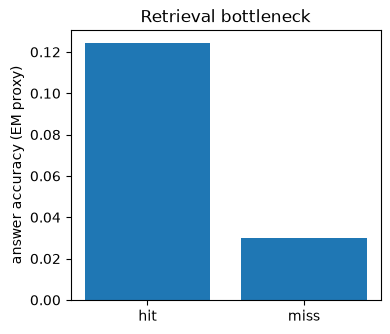

In [9]:
PUNCT = set(string.punctuation + '\u2018\u2019\u00b4`_')
def _pre(a):
    a = a.lower().replace('\n', ' ').replace('\t', ' ').strip()
    a = ''.join('' if c in PUNCT else c for c in a)
    a = re.sub(r'\b(the answer is|a|an|the)\b', ' ', a)
    return ' '.join(a.split())
def correct(rec):
    if rec.get('prediction') is None:
        return False
    ref = str(rec['answer'])
    if rec['question_type'] == 'multi_answer':
        R = [x for x in (_pre(a) for a in ref.split('|')[0].split('&&')) if x]
        C = [x for x in (_pre(a) for a in rec['prediction'].replace(' and ', ',').replace(' & ', ',').split(',')) if x]
        u = len(set(R) | set(C)); return len(set(R) & set(C)) / u >= 0.5 if u else False
    return _pre(ref) == _pre(rec['prediction'])
def norm(u):
    if not u:
        return u
    u = re.sub(r'^https?://', '', u.strip().lower())
    return u.replace('en.m.wikipedia.org', 'en.wikipedia.org').rstrip('/')
def cands(p):
    rc = p.get('retrieved_context') or {}
    cs = [c['wiki_url'] for c in rc.get('candidates', [])] or ([rc['wiki_url']] if rc.get('wiki_url') else [])
    return [norm(u) for u in cs]

gt = {x['unique_id']: norm(x.get('wikipedia_url')) for x in json.load(open(BASE + '/encyclopedic_test_subset.json'))}

# best variant available
pred_file = OUT + '/predictions_B5_top50_n20.jsonl'
if not os.path.exists(pred_file):
    pred_file = OUT + '/predictions_B4.jsonl'
preds = [json.loads(l) for l in open(pred_file) if l.strip()]
hit = [p for p in preds if gt.get(p['unique_id']) in cands(p)]
miss = [p for p in preds if gt.get(p['unique_id']) not in cands(p)]
acc = lambda s: sum(correct(p) for p in s) / len(s) if s else 0
print('file:', os.path.basename(pred_file))
print('recall (article retrieved): %.1f%%' % (100 * len(hit) / len(preds)))
print('accuracy | HIT : %.3f (n=%d)' % (acc(hit), len(hit)))
print('accuracy | MISS: %.3f (n=%d)' % (acc(miss), len(miss)))
plt.figure(figsize=(4, 3.5)); plt.bar(['hit', 'miss'], [acc(hit), acc(miss)])
plt.ylabel('answer accuracy (EM proxy)'); plt.title('Retrieval bottleneck'); plt.show()

## top-k and top-n must be scaled together
Recall rises with k, but the reranker dilutes; a larger top-n recovers the answer paragraph that slipped in the ranking. `acc_hit` is backed out from `overall = recall*acc_hit + (1-recall)*acc_miss` with `acc_miss = A`.

The top-n effect is an inverted-U at fixed top-k: at top-50, n5=0.376 -> n20=0.401 (peak) -> n30=0.385. Too few paragraphs lose the answer, too many drown it in noise; the balanced operating point is top-50 / n20.

In [10]:
dump_path = OUT + '/retrieval_topk50.jsonl'
if os.path.exists(dump_path):
    dump = [json.loads(l) for l in open(dump_path) if l.strip()]
    def recall_at(k):
        h = 0
        for r in dump:
            g = norm(r['wikipedia_url'])
            if g and g in [norm(c['wiki_url']) for c in r['candidates'][:k]]:
                h += 1
        return h / len(dump)
    acc_miss = json.load(open(OUT + '/results.json'))['accuracy_overall']
    combos = [(5, 3, 'results_B4.json'), (50, 5, 'results_B5_top50.json'), (50, 20, 'results_B5_top50_n20.json'), (50, 30, 'results_B5_top50_n30.json')]
    print('%-14s %-8s %-9s %s' % ('k / top-n', 'recall', 'overall', 'acc_hit'))
    for k, n, f in combos:
        if os.path.exists(OUT + '/' + f):
            rec = recall_at(k); ov = json.load(open(OUT + '/' + f))['accuracy_overall']
            print('top%-3d n=%-6d %-8.1f %-9.3f %.3f' % (k, n, 100 * rec, ov, (ov - (1 - rec) * acc_miss) / rec))
else:
    print('run scripts/run_recall.sh to populate the recall dump')

k / top-n      recall   overall   acc_hit
top5   n=3      27.8     0.360     0.659
top50  n=5      46.7     0.376     0.526
top50  n=20     46.7     0.401     0.579
top50  n=30     46.7     0.385     0.545


## Observations

| Variant | What it tests | Verdict |
|---|---|---|
| A | no retrieval (floor) | reference 0.245 |
| B1 top1 + first3 | cheapest RAG | small gain over A |
| B2 top1 + allsec | more context, 1 article | all sections > first 3 |
| B2.1 top5 + allsec | more candidate articles | more candidates help (0.347) |
| B3 top5 + CLIP | question-aware rerank (CLIP) | **hurts** — discards good paragraphs |
| B4 top5 + cross3 | cross-encoder rerank | good reranker ≈ give-all (0.360) |
| B4.1 top5 + cross15 | more paragraphs @ top-5 | no gain — top-n second-order at low top-k |
| B5 top20/top50 + cross5 | higher recall | recall up (28→47%) but reranker dilutes |
| B5 top50 + cross20 | high recall + big top-n | **best (0.401)** — top-k and top-n scaled together |

**What works:** cross-encoder rerank (never CLIP); scaling top-k *and* top-n together; a generous reranked set (Qwen is robust to noise).

**What doesn't:** CLIP rerank (worse than none); raising top-k alone with a small top-n; more paragraphs at low top-k.

**Bottleneck:** retrieval recall (see `../03_recall_curve`). When the right article is found the VLM answers ~66%; it isn't found ~53–72% of the time.

**Prompt-style sweep (tested, dropped):** a system-prompt sweep (strict / fallback / reasoning / combined) on the B4 setup moved accuracy by only ~1 pt; `fallback` (let the VLM use its own knowledge) actually *hurt* (penalized hallucination). Prompting is not a useful lever for B — the gain is in retrieval.

**Next:** agentic RAG (C), targeting retrieval recall (the 53% of misses).